In [ ]:
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 650.7 kB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sqlalchemy import create_engine, text

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ONINE_FOOD_DELIVERY_ANALYSIS - ONINE_FOOD_DELIVERY_ANALYSIS.csv to ONINE_FOOD_DELIVERY_ANALYSIS - ONINE_FOOD_DELIVERY_ANALYSIS (1).csv


In [ ]:
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 100000
Columns: 25


In [ ]:
df.head()

,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Final_Amount,Payment_Mode,Order_Status,Cancellation_Reason,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin
0,ORD000001,CUST6948,19.0,Male,NaN,Central,RES936,Restaurant_29,Chinese,10/20/2024,...,NaN,UPI,Delivered,NaN,DP563,5.0,4.4,Weekend,True,0.13
1,ORD000002,CUST6515,NaN,Female,Chennai,North,RES689,Restaurant_419,Chinese,8/12/2024,...,4849.0,COD,Delivered,NaN,DP369,5.0,4.7,Weekday,True,0.48
2,ORD000003,CUST1765,NaN,Male,Delhi,NaN,RES723,Restaurant_244,Arabian,12/8/2024,...,737.0,Wallet,Delivered,NaN,DP580,4.0,4.9,Weekend,True,0.08
3,ORD000004,CUST2744,NaN,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,10/8/2024,...,NaN,UPI,Cancelled,Late Delivery,DP155,2.0,3.4,Weekday,NaN,0.04
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2/4/2024,...,352.0,Card,Delivered,NaN,DP728,2.0,4.4,Weekend,False,0.12


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print(df.columns.tolist())
df.info()
df.describe(include="all")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print("Duplicate rows:", df.duplicated().sum())

Number of rows: 100000
Number of columns: 25
['Order_ID', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'City', 'Area', 'Restaurant_ID', 'Restaurant_Name', 'Cuisine_Type', 'Order_Date', 'Order_Time', 'Delivery_Time_Min', 'Distance_km', 'Order_Value', 'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status', 'Cancellation_Reason', 'Delivery_Partner_ID', 'Delivery_Rating', 'Restaurant_Rating', 'Order_Day', 'Peak_Hour', 'Profit_Margin']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Order_ID             100000 non-null  object 
 1   Customer_ID          100000 non-null  object 
 2   Customer_Age         49907 non-null   float64
 3   Customer_Gender      75144 non-null   object 
 4   City                 83274 non-null   object 
 5   Area                 83315 non-null   object 
 6   Restaurant_ID        1000

In [ ]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print("Rows after removing duplicates:", len(df_clean))
df_clean["Order_Date"] = pd.to_datetime(
    df_clean["Order_Date"],
    errors="coerce"
)
df_clean["Order_Date"].head()

Rows after removing duplicates: 100000


,Order_Date
0,2024-10-20
1,2024-08-12
2,2024-12-08
3,2024-10-08
4,2024-02-04


In [ ]:
numeric_columns = [
    "Customer_Age",
    "Delivery_Time_Min",
    "Distance_km",
    "Order_Value",
    "Discount_Applied",
    "Final_Amount",
    "Delivery_Rating",
    "Restaurant_Rating",
    "Profit_Margin"
]
for column in numeric_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )
    df_clean[numeric_columns].dtypes

In [ ]:
df_clean.loc[
    (df_clean["Customer_Age"] < 18) |
    (df_clean["Customer_Age"] > 100),
    "Customer_Age"
] = np.nan
df_clean["Customer_Age"] = df_clean["Customer_Age"].fillna(
    df_clean["Customer_Age"].median()
)

In [ ]:
df_clean.loc[
    (df_clean["Delivery_Time_Min"] < 0) |
    (df_clean["Delivery_Time_Min"] > 300),
    "Delivery_Time_Min"
] = np.nan
df_clean["Delivery_Time_Min"] = df_clean[
    "Delivery_Time_Min"
].fillna(
    df_clean["Delivery_Time_Min"].median()
)

In [ ]:
df_clean.loc[
    (df_clean["Distance_km"] < 0) |
    (df_clean["Distance_km"] > 100),
    "Distance_km"
] = np.nan
df_clean["Distance_km"] = df_clean[
    "Distance_km"
].fillna(
    df_clean["Distance_km"].median()
)

In [ ]:
df_clean.loc[
    df_clean["Order_Value"] < 0,
    "Order_Value"
] = np.nan
df_clean["Order_Value"] = df_clean[
    "Order_Value"
].fillna(
    df_clean["Order_Value"].median()
)

In [ ]:
df_clean.loc[
    df_clean["Discount_Applied"] < 0,
    "Discount_Applied"
] = np.nan
df_clean["Discount_Applied"] = df_clean[
    "Discount_Applied"
].fillna(0)

In [ ]:
df_clean.loc[
    (df_clean["Delivery_Rating"] < 1) |
    (df_clean["Delivery_Rating"] > 5),
    "Delivery_Rating"
] = np.nan
df_clean.loc[
    (df_clean["Restaurant_Rating"] < 1) |
    (df_clean["Restaurant_Rating"] > 5),
    "Restaurant_Rating"
] = np.nan

In [ ]:
df_clean["Restaurant_Rating"] = df_clean[
    "Restaurant_Rating"
].fillna(
    df_clean["Restaurant_Rating"].median()
)

In [ ]:
categorical_columns = [
    "Customer_Gender",
    "City",
    "Area",
    "Cuisine_Type",
    "Payment_Mode",
    "Cancellation_Reason",
    "Peak_Hour"
]
for column in categorical_columns:
    df_clean[column] = (
        df_clean[column]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

In [ ]:
df_clean[categorical_columns].head()

,Customer_Gender,City,Area,Cuisine_Type,Payment_Mode,Cancellation_Reason,Peak_Hour
0,Male,Unknown,Central,Chinese,UPI,Unknown,True
1,Female,Chennai,North,Chinese,COD,Unknown,True
2,Male,Delhi,Unknown,Arabian,Wallet,Unknown,True
3,Male,Mumbai,Central,Chinese,UPI,Late Delivery,Unknown
4,Female,Chennai,South,Chinese,Card,Unknown,False


In [ ]:
df_clean["Order_Month"] = (
    df_clean["Order_Date"]
    .dt.to_period("M")
    .astype(str)
)
df_clean["Order_Year"] = (
    df_clean["Order_Date"]
    .dt.year
)
df_clean["Customer_Age_Group"] = pd.cut(
    df_clean["Customer_Age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-50",
        "51-65",
        "66+"
    ],
    include_lowest=True
)
df_clean["Customer_Age_Group"].value_counts()

,count
Customer_Age_Group,
36-50,67609
26-35,11653
51-65,11492
18-25,9246
66+,0


In [ ]:
df_clean["Delivery_Performance"] = pd.cut(
    df_clean["Delivery_Time_Min"],
    bins=[-np.inf, 30, 60, 120, np.inf],
    labels=[
        "Fast",
        "Normal",
        "Delayed",
        "Highly Delayed"
    ]
)
df_clean["Delivery_Performance"].value_counts()

,count
Delivery_Performance,
Delayed,40141
Highly Delayed,33246
Normal,19374
Fast,7239


In [ ]:
df_clean["Revenue"] = np.where(
    df_clean["Order_Status"] == "Delivered",
    df_clean["Final_Amount"],
    0
)
df_clean["Revenue"].sum()

np.float64(73863430.0)

In [ ]:
df_clean["Profit"] = (
    df_clean["Revenue"] *
    df_clean["Profit_Margin"]
)
df_clean["Profit"].sum()

np.float64(11106395.31)

In [ ]:
df_clean["Cancellation_Flag"] = np.where(
    df_clean["Order_Status"] == "Cancelled",
    1,
    0
)

In [ ]:
df_clean["Delivered_Flag"] = np.where(
    df_clean["Order_Status"] == "Delivered",
    1,
    0
)

In [ ]:
print("Final rows:", len(df_clean))
print("Final columns:", len(df_clean.columns))

Final rows: 100000
Final columns: 33


In [ ]:
df_clean.isnull().sum().sort_values(ascending=False)
print("Duplicates:", df_clean.duplicated().sum())
df_clean.head()

Duplicates: 0


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Peak_Hour,Profit_Margin,Order_Month,Order_Year,Customer_Age_Group,Delivery_Performance,Revenue,Profit,Cancellation_Flag,Delivered_Flag
0,ORD000001,CUST6948,19.0,Male,Unknown,Central,RES936,Restaurant_29,Chinese,2024-10-20,...,True,0.13,2024-10,2024.0,18-25,Highly Delayed,NaN,NaN,0,1
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,...,True,0.48,2024-08,2024.0,36-50,Fast,4849.0,2327.52,0,1
2,ORD000003,CUST1765,39.0,Male,Delhi,Unknown,RES723,Restaurant_244,Arabian,2024-12-08,...,True,0.08,2024-12,2024.0,36-50,Highly Delayed,737.0,58.96,0,1
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,...,Unknown,0.04,2024-10,2024.0,36-50,Highly Delayed,0.0,0.00,1,0
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,...,False,0.12,2024-02,2024.0,51-65,Normal,352.0,42.24,0,1


In [ ]:
df_clean.to_csv(
    "food_delivery_cleaned.csv",
    index=False
)

In [ ]:
from google.colab import files
files.download("food_delivery_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
total_orders = len(df_clean)

delivered_orders = (
    df_clean["Order_Status"] == "Delivered"
).sum()

cancelled_orders = (
    df_clean["Order_Status"] == "Cancelled"
).sum()

total_revenue = df_clean["Revenue"].sum()

total_profit = df_clean["Profit"].sum()

average_order_value = df_clean.loc[
    df_clean["Order_Status"] == "Delivered",
    "Final_Amount"
].mean()

average_delivery_time = df_clean.loc[
    df_clean["Order_Status"] == "Delivered",
    "Delivery_Time_Min"
].mean()

cancellation_rate = (
    cancelled_orders / total_orders
) * 100

profit_margin = (
    total_profit / total_revenue
) * 100

print("Total Orders:", total_orders)
print("Delivered Orders:", delivered_orders)
print("Cancelled Orders:", cancelled_orders)
print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Average Order Value:", average_order_value)
print("Average Delivery Time:", average_delivery_time)
print("Cancellation Rate:", cancellation_rate)
print("Profit Margin:", profit_margin)

Total Orders: 100000
Delivered Orders: 84964
Cancelled Orders: 15036
Total Revenue: 73863430.0
Total Profit: 11106395.31
Average Order Value: 1964.8709831879123
Average Delivery Time: 124.9770020243868
Cancellation Rate: 15.036
Profit Margin: 15.036392582906046


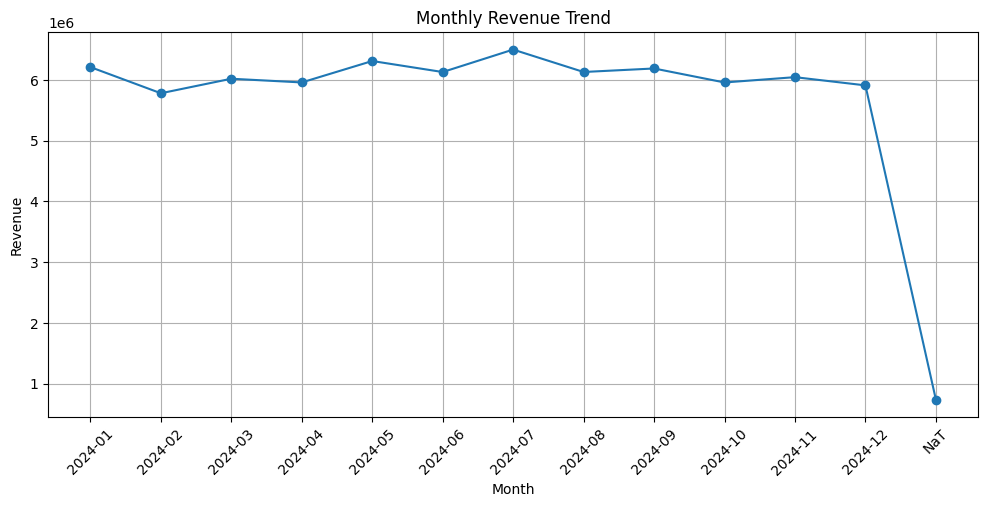

In [ ]:
monthly = df_clean.groupby(
    "Order_Month"
).agg(
    Orders=("Order_ID", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).reset_index()

monthly
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Order_Month"],
    monthly["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [ ]:
city_analysis = df_clean.groupby(
    "City"
).agg(
    Orders=("Order_ID", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Avg_Delivery_Time=("Delivery_Time_Min", "mean")
).reset_index()

city_analysis = city_analysis.sort_values(
    "Revenue",
    ascending=False
)

city_analysis

,City,Orders,Revenue,Profit,Avg_Delivery_Time
5,Unknown,16726,12446811.0,1850292.10,125.110307
0,Bangalore,16732,12429492.0,1889947.11,124.373297
1,Chennai,16470,12414677.0,1828814.49,124.549423
3,Hyderabad,16884,12299756.0,1894851.87,125.031805
4,Mumbai,16493,12188864.0,1829650.51,125.937246
2,Delhi,16695,12083830.0,1812839.23,124.896376


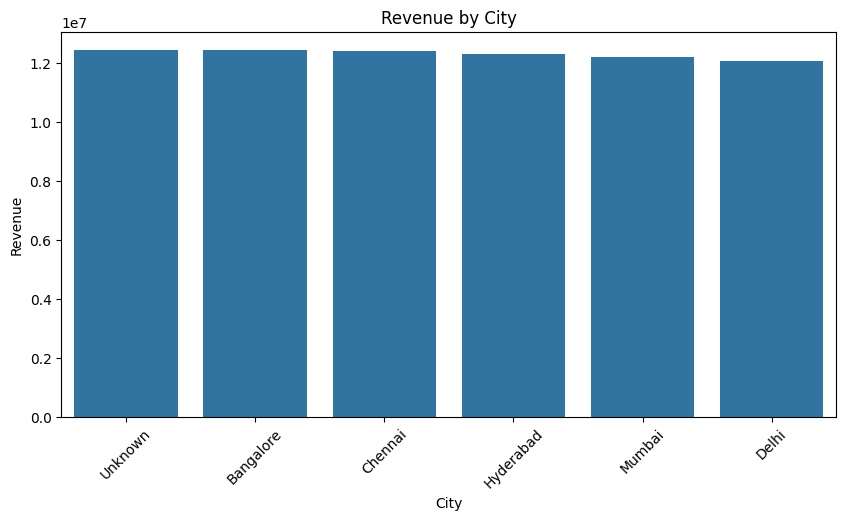

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=city_analysis,
    x="City",
    y="Revenue"
)

plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

In [ ]:
city_analysis.iloc[0]

,5
City,Unknown
Orders,16726
Revenue,12446811.0
Profit,1850292.1
Avg_Delivery_Time,125.110307


In [ ]:
cuisine_analysis = df_clean.groupby(
    "Cuisine_Type"
).agg(
    Orders=("Order_ID", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Avg_Rating=("Restaurant_Rating", "mean")
).reset_index()

cuisine_analysis = cuisine_analysis.sort_values(
    "Revenue",
    ascending=False
)

cuisine_analysis

,Cuisine_Type,Orders,Revenue,Profit,Avg_Rating
5,Unknown,16885,12675140.0,1948565.74,4.019064
4,Mexican,16602,12473718.0,1923704.61,4.019516
2,Indian,16685,12341357.0,1830258.17,4.022697
1,Chinese,16651,12255955.0,1796826.71,4.013717
0,Arabian,16658,12163043.0,1804698.17,4.023178
3,Italian,16519,11954217.0,1802341.91,4.019360


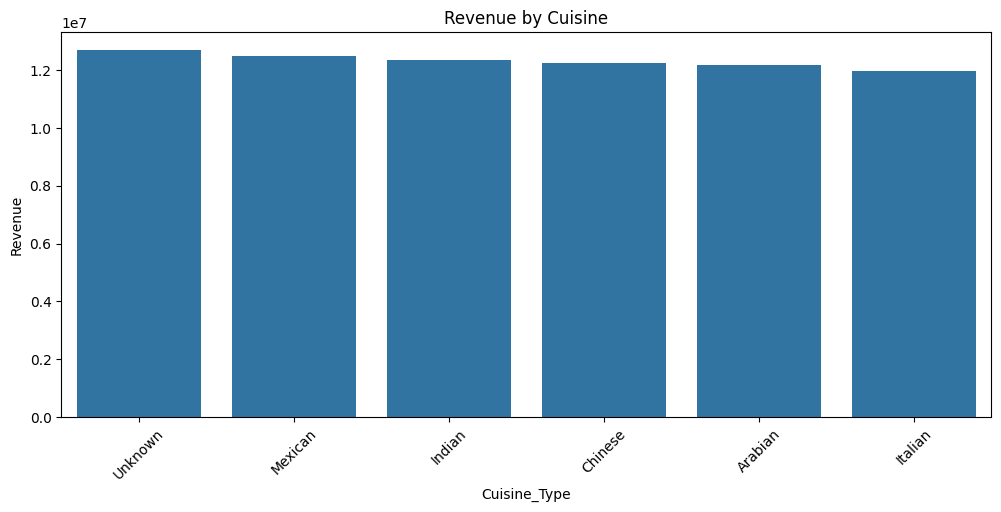

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=cuisine_analysis,
    x="Cuisine_Type",
    y="Revenue"
)

plt.title("Revenue by Cuisine")
plt.xticks(rotation=45)
plt.show()

In [ ]:
top_customers = df_clean.groupby(
    "Customer_ID"
).agg(
    Orders=("Order_ID", "count"),
    Total_Spend=("Revenue", "sum")
).reset_index()

top_customers = top_customers.sort_values(
    "Total_Spend",
    ascending=False
).head(10)

top_customers

,Customer_ID,Orders,Total_Spend
7523,CUST8524,16,36163.0
2471,CUST3471,21,32819.0
4408,CUST5409,16,31954.0
7121,CUST8122,20,30037.0
965,CUST1965,16,29816.0
2365,CUST3365,21,29183.0
5251,CUST6252,20,28982.0
5705,CUST6706,18,28904.0
2681,CUST3682,17,28885.0
1380,CUST2380,14,27933.0


In [ ]:
fig = px.bar(
    top_customers,
    x="Total_Spend",
    y="Customer_ID",
    orientation="h",
    title="Top 10 Customers by Spending"
)

fig.show()

In [ ]:
customer_orders = df_clean.groupby(
    "Customer_ID"
)["Order_ID"].count().reset_index()

customer_orders["Customer_Type"] = np.where(
    customer_orders["Order_ID"] == 1,
    "One-time",
    "Returning"
)

customer_type = (
    customer_orders["Customer_Type"]
    .value_counts()
    .reset_index()
)

customer_type.columns = [
    "Customer_Type",
    "Customers"
]

customer_type

,Customer_Type,Customers
0,Returning,8993
1,One-time,6


In [ ]:
fig = px.pie(
    customer_type,
    names="Customer_Type",
    values="Customers",
    hole=0.4,
    title="One-Time vs Returning Customers"
)

fig.show()

In [ ]:
day_analysis = df_clean.groupby(
    "Order_Day"
).agg(
    Orders=("Order_ID", "count"),
    Revenue=("Revenue", "sum")
).reset_index()

day_analysis

,Order_Day,Orders,Revenue
0,Weekday,71370,52696857.0
1,Weekend,28630,21166573.0


In [ ]:
fig = px.bar(
    day_analysis,
    x="Order_Day",
    y="Orders",
    title="Weekday vs Weekend Orders"
)

fig.show()

In [ ]:
peak_analysis = df_clean.groupby(
    "Peak_Hour"
).agg(
    Orders=("Order_ID", "count"),
    Revenue=("Revenue", "sum"),
    Avg_Delivery_Time=("Delivery_Time_Min", "mean")
).reset_index()

peak_analysis

,Peak_Hour,Orders,Revenue,Avg_Delivery_Time
0,False,33585,24832248.0,125.334346
1,True,33453,24405278.0,124.687801
2,Unknown,32962,24625904.0,124.921667


In [ ]:
fig = px.bar(
    peak_analysis,
    x="Peak_Hour",
    y="Orders",
    title="Orders by Peak Hour"
)

fig.show()

In [ ]:
delivery_analysis = df_clean[
    df_clean["Order_Status"] == "Delivered"
].groupby("City").agg(
    Avg_Delivery_Time=("Delivery_Time_Min", "mean"),
    Avg_Distance=("Distance_km", "mean"),
    Avg_Delivery_Rating=("Delivery_Rating", "mean")
).reset_index()

delivery_analysis

,City,Avg_Delivery_Time,Avg_Distance,Avg_Delivery_Rating
0,Bangalore,124.328087,14.290810,2.989338
1,Chennai,124.340220,14.279161,2.978121
2,Delhi,125.031874,14.282466,2.987009
3,Hyderabad,125.178068,14.202257,3.017413
4,Mumbai,125.789267,14.368698,2.987515
5,Unknown,125.194214,14.291822,2.991715


In [ ]:
fig = px.bar(
    delivery_analysis,
    x="City",
    y="Avg_Delivery_Time",
    title="Average Delivery Time by City"
)

fig.show()

In [ ]:
delivery_data = df_clean[
    df_clean["Order_Status"] == "Delivered"
]

In [ ]:
fig = px.scatter(
    delivery_data,
    x="Distance_km",
    y="Delivery_Time_Min",
    color="City",
    title="Distance vs Delivery Time"
)

fig.show()

In [ ]:
correlation = delivery_data[
    ["Distance_km", "Delivery_Time_Min"]
].corr()

correlation

,Distance_km,Delivery_Time_Min
Distance_km,1.00000,0.00477
Delivery_Time_Min,0.00477,1.00000


In [ ]:
cancellation = df_clean[
    df_clean["Order_Status"] == "Cancelled"
]

In [ ]:
cancellation_reasons = (
    cancellation["Cancellation_Reason"]
    .value_counts()
    .reset_index()
)

cancellation_reasons.columns = [
    "Reason",
    "Cancellations"
]

cancellation_reasons

,Reason,Cancellations
0,Unknown,6005
1,Late Delivery,3059
2,Customer Cancelled,2993
3,Restaurant Issue,2979


In [ ]:
fig = px.pie(
    cancellation_reasons,
    names="Reason",
    values="Cancellations",
    hole=0.4,
    title="Cancellation Reasons"
)

fig.show()

In [ ]:
city_cancel = df_clean.groupby(
    "City"
).agg(
    Total_Orders=("Order_ID", "count"),
    Cancelled=("Cancellation_Flag", "sum")
).reset_index()

city_cancel["Cancellation_Rate"] = (
    city_cancel["Cancelled"] /
    city_cancel["Total_Orders"]
) * 100

city_cancel = city_cancel.sort_values(
    "Cancellation_Rate",
    ascending=False
)

city_cancel

,City,Total_Orders,Cancelled,Cancellation_Rate
3,Hyderabad,16884,2558,15.150438
1,Chennai,16470,2482,15.069824
5,Unknown,16726,2520,15.066364
2,Delhi,16695,2514,15.058401
0,Bangalore,16732,2501,14.947406
4,Mumbai,16493,2461,14.921482


In [ ]:
fig = px.bar(
    city_cancel,
    x="City",
    y="Cancellation_Rate",
    title="Cancellation Rate by City"
)

fig.show()

In [ ]:
restaurant_analysis = df_clean.groupby(
    ["Restaurant_ID", "Restaurant_Name"]
).agg(
    Orders=("Order_ID", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Rating=("Restaurant_Rating", "mean")
).reset_index()

top_restaurants = restaurant_analysis.sort_values(
    "Revenue",
    ascending=False
).head(10)

top_restaurants

,Restaurant_ID,Restaurant_Name,Orders,Revenue,Profit,Rating
8100,RES180,Restaurant_269,3,12229.0,3686.79,4.300000
44663,RES546,Restaurant_79,3,11435.0,-127.84,3.733333
6989,RES169,Restaurant_244,3,10972.0,1565.97,4.200000
12132,RES220,Restaurant_485,3,10947.0,3774.91,4.133333
7765,RES177,Restaurant_173,3,10553.0,960.53,4.333333
24035,RES340,Restaurant_480,3,10388.0,3275.98,3.933333
20892,RES309,Restaurant_431,2,9750.0,3264.60,3.800000
8614,RES185,Restaurant_361,2,9729.0,338.49,3.600000
42906,RES529,Restaurant_388,2,9714.0,2110.98,3.850000
46279,RES563,Restaurant_35,2,9619.0,1389.87,3.900000


In [ ]:
fig = px.bar(
    top_restaurants,
    x="Restaurant_Name",
    y="Revenue",
    title="Top 10 Restaurants by Revenue"
)

fig.show()

In [ ]:
profit_city = df_clean.groupby(
    "City"
).agg(
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).reset_index()

profit_city["Profit_Margin_Pct"] = (
    profit_city["Profit"] /
    profit_city["Revenue"]
) * 100

profit_city = profit_city.sort_values(
    "Profit",
    ascending=False
)

profit_city

,City,Revenue,Profit,Profit_Margin_Pct
3,Hyderabad,12299756.0,1894851.87,15.405605
0,Bangalore,12429492.0,1889947.11,15.205345
5,Unknown,12446811.0,1850292.10,14.865592
4,Mumbai,12188864.0,1829650.51,15.010837
1,Chennai,12414677.0,1828814.49,14.731068
2,Delhi,12083830.0,1812839.23,15.002191


In [ ]:
fig = px.bar(
    profit_city,
    x="City",
    y=["Revenue", "Profit"],
    barmode="group",
    title="Revenue vs Profit by City"
)

fig.show()

In [ ]:
!pip install pymysql sqlalchemy

In [ ]:
!pip install mysql-connector-python

In [ ]:
import mysql.connector

conn = mysql.connector.connect(
    host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
    port=4000,
    user="2ow7fzo5mRAMRmu.root",
    password="VORWif0dPOWA4Uuh",
    database="food_delivery_db"
)

print("Connected to TiDB successfully!")

Connected to TiDB successfully!


In [ ]:
cursor = conn.cursor()

cursor.execute("SHOW TABLES")

for table in cursor.fetchall():
    print(table[0])

food_delivery_orders


In [ ]:
cursor.execute("SELECT * FROM food_delivery_orders")

for row in cursor.fetchall():
    print(row)

Streaming output truncated to the last 5000 lines.
('ORD095001', 'CUST3606', Decimal('51.00'), 'Unknown', 'Hyderabad', 'Unknown', 'RES463', 'Restaurant_63', 'Arabian', datetime.date(2024, 2, 1), datetime.timedelta(0), Decimal('120.00'), Decimal('2.21'), Decimal('1197.00'), Decimal('20.00'), None, 'Unknown', 'Delivered', 'Unknown', 'DP486', Decimal('2.00'), Decimal('4.90'), 'Weekday', 'Unknown', Decimal('0.3500'), '2024-02', 2024, '51-65', 'Delayed', None, None, 0, 1)
('ORD095002', 'CUST2654', Decimal('60.00'), 'Male', 'Delhi', 'Unknown', 'RES779', 'Restaurant_437', 'Indian', datetime.date(2024, 6, 20), datetime.timedelta(0), Decimal('131.00'), Decimal('1.29'), Decimal('1033.00'), Decimal('300.00'), Decimal('733.00'), 'Unknown', 'Delivered', 'Unknown', 'DP654', None, Decimal('3.60'), 'Weekday', 'Unknown', Decimal('0.2700'), '2024-06', 2024, '51-65', 'Highly Delayed', Decimal('733.00'), Decimal('197.91'), 0, 1)
('ORD095003', 'CUST2689', Decimal('24.00'), 'Male', 'Chennai', 'East', 'RES13

In [ ]:
pip install streamlit pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.5 MB/s eta 0:00:00


In [ ]:
%%writefile /content/app.py
import streamlit as st
import pymysql
import pandas as pd
import plotly.express as px

# Database connection
connection = pymysql.connect(
    host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
    port=4000,
    user="2ow7fzo5mRAMRmu.root",
    password="VORWif0dPOWA4Uuh",
    database="food_delivery_db",
    ssl={"ssl": {}}
)
# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="Online Food Delivery Analytics",
    page_icon="🍔",
    layout="wide"
)


# =========================================================
# TITLE
# =========================================================

st.title("🍔 Online Food Delivery Analytics")

st.write(
    "Data-Driven Business Insights Dashboard"
)


# =========================================================
# DATABASE CONNECTION
# =========================================================

@st.cache_resource
def get_connection():

    return pymysql.connect(
        host="gateway01.ap-southeast-1.prod.aws.tidbcloud.com",
        port=4000,
        user="2ow7fzo5mRAMRmu.root",
        password="VORWif0dPOWA4Uuh",
        database="food_delivery_db",
        ssl={}
    )

    return engine

# =========================================================
# LOAD DATA
# =========================================================

@st.cache_data(ttl=300)
def load_data():
    engine = get_connection()


    query = """
    SELECT *
    FROM food_delivery_orders
    """

    data = pd.read_sql(
        query,
        engine
    )

    return data


# =========================================================
# CONNECT TO DATABASE
# =========================================================

try:

    df = load_data()

    st.success(
        f"✅ TiDB Connected Successfully | "
        f"{len(df):,} food delivery records loaded"
    )

except Exception as e:

    st.error(
        f"❌ Database connection failed: {e}"
    )

    st.stop()


# =========================================================
# CHECK DATA
# =========================================================

if df.empty:

    st.warning(
        "⚠️ No food delivery records found in the database."
    )

    st.stop()


# =========================================================
# DATA PREPARATION
# =========================================================

if "order_date" in df.columns:

    df["order_date"] = pd.to_datetime(
        df["order_date"],
        errors="coerce"
    )


numeric_columns = [
    "revenue",
    "profit",
    "final_amount",
    "delivery_time_min",
    "distance_km"
]


for column in numeric_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.header("🔎 Filters")


# =========================================================
# CITY FILTER
# =========================================================

if "city" in df.columns:

    city_list = (
        df["city"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    city_list = sorted(city_list)

    selected_city = st.sidebar.multiselect(
        "City",
        city_list,
        default=city_list
    )

else:

    selected_city = []


# =========================================================
# CUISINE FILTER
# =========================================================

if "cuisine_type" in df.columns:

    cuisine_list = (
        df["cuisine_type"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    cuisine_list = sorted(cuisine_list)

    selected_cuisine = st.sidebar.multiselect(
        "Cuisine",
        cuisine_list,
        default=cuisine_list
    )

else:

    selected_cuisine = []


# =========================================================
# ORDER STATUS FILTER
# =========================================================

if "order_status" in df.columns:

    status_list = (
        df["order_status"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    status_list = sorted(status_list)

    selected_status = st.sidebar.multiselect(
        "Order Status",
        status_list,
        default=status_list
    )

else:

    selected_status = []


# =========================================================
# APPLY FILTERS
# =========================================================

filtered_df = df.copy()


# City

if selected_city:

    filtered_df = filtered_df[
        filtered_df["city"]
        .astype(str)
        .isin(selected_city)
    ]


# Cuisine

if selected_cuisine:

    filtered_df = filtered_df[
        filtered_df["cuisine_type"]
        .astype(str)
        .isin(selected_cuisine)
    ]


# Order Status

if selected_status:

    filtered_df = filtered_df[
        filtered_df["order_status"]
        .astype(str)
        .isin(selected_status)
    ]


# =========================================================
# KPI SECTION
# =========================================================

st.header("📊 Business Overview")


# =========================================================
# KPI CALCULATIONS
# =========================================================

total_orders = len(filtered_df)


if "revenue" in filtered_df.columns:

    total_revenue = filtered_df["revenue"].sum()

else:

    total_revenue = 0


if "profit" in filtered_df.columns:

    total_profit = filtered_df["profit"].sum()

else:

    total_profit = 0


if "order_status" in filtered_df.columns:

    delivered_orders = (
        filtered_df["order_status"] == "Delivered"
    ).sum()

    cancelled_orders = (
        filtered_df["order_status"] == "Cancelled"
    ).sum()

else:

    delivered_orders = 0
    cancelled_orders = 0


if (
    "order_status" in filtered_df.columns
    and "final_amount" in filtered_df.columns
):

    avg_order_value = filtered_df.loc[
        filtered_df["order_status"] == "Delivered",
        "final_amount"
    ].mean()

else:

    avg_order_value = np.nan


if (
    "order_status" in filtered_df.columns
    and "delivery_time_min" in filtered_df.columns
):

    avg_delivery_time = filtered_df.loc[
        filtered_df["order_status"] == "Delivered",
        "delivery_time_min"
    ].mean()

else:

    avg_delivery_time = np.nan


cancellation_rate = (
    cancelled_orders /
    total_orders *
    100
    if total_orders > 0
    else 0
)


profit_margin = (
    total_profit /
    total_revenue *
    100
    if total_revenue > 0
    else 0
)


# =========================================================
# KPI ROW 1
# =========================================================

col1, col2, col3, col4 = st.columns(4)


with col1:

    st.metric(
        "🛒 Total Orders",
        f"{total_orders:,}"
    )


with col2:

    st.metric(
        "💰 Total Revenue",
        f"₹{total_revenue:,.0f}"
    )


with col3:

    st.metric(
        "📈 Total Profit",
        f"₹{total_profit:,.0f}"
    )


with col4:

    if pd.notna(avg_order_value):

        st.metric(
            "💵 Average Order Value",
            f"₹{avg_order_value:,.0f}"
        )

    else:

        st.metric(
            "💵 Average Order Value",
            "N/A"
        )


# =========================================================
# KPI ROW 2
# =========================================================

col1, col2, col3, col4 = st.columns(4)


with col1:

    if pd.notna(avg_delivery_time):

        st.metric(
            "🚚 Avg Delivery Time",
            f"{avg_delivery_time:.1f} min"
        )

    else:

        st.metric(
            "🚚 Avg Delivery Time",
            "N/A"
        )


with col2:

    st.metric(
        "❌ Cancellation Rate",
        f"{cancellation_rate:.2f}%"
    )


with col3:

    st.metric(
        "📊 Profit Margin",
        f"{profit_margin:.2f}%"
    )


with col4:

    st.metric(
        "✅ Delivered Orders",
        f"{delivered_orders:,}"
    )


# =========================================================
# MONTHLY REVENUE
# =========================================================

st.header("📈 Monthly Revenue")


if (
    "order_date" in filtered_df.columns
    and "revenue" in filtered_df.columns
    and "order_id" in filtered_df.columns
):

    monthly_data = filtered_df.copy()

    monthly_data["month"] = (
        monthly_data["order_date"]
        .dt.to_period("M")
        .astype(str)
    )

    monthly_data = (
        monthly_data
        .groupby("month")
        .agg(
            revenue=("revenue", "sum"),
            orders=("order_id", "count")
        )
        .reset_index()
    )

    if not monthly_data.empty:

        fig_monthly = px.line(
            monthly_data,
            x="month",
            y="revenue",
            markers=True,
            title="Monthly Revenue"
        )

        st.plotly_chart(
            fig_monthly,
            use_container_width=True
        )


# =========================================================
# CITY ANALYSIS
# =========================================================

st.header("🏙️ City Performance")


if all(
    column in filtered_df.columns
    for column in ["city", "order_id", "revenue", "profit"]
):

    city_data = (
        filtered_df
        .groupby("city")
        .agg(
            orders=("order_id", "count"),
            revenue=("revenue", "sum"),
            profit=("profit", "sum")
        )
        .reset_index()
    )

    city_data = city_data.sort_values(
        "revenue",
        ascending=False
    )

    if not city_data.empty:

        fig_city = px.bar(
            city_data,
            x="city",
            y="revenue",
            text_auto=".2s",
            title="Revenue by City"
        )

        st.plotly_chart(
            fig_city,
            use_container_width=True
        )


# =========================================================
# CUISINE ANALYSIS
# =========================================================

st.header("🍽️ Cuisine Performance")


if all(
    column in filtered_df.columns
    for column in [
        "cuisine_type",
        "order_id",
        "revenue"
    ]
):

    cuisine_data = (
        filtered_df
        .groupby("cuisine_type")
        .agg(
            orders=("order_id", "count"),
            revenue=("revenue", "sum")
        )
        .reset_index()
    )

    cuisine_data = cuisine_data.sort_values(
        "revenue",
        ascending=False
    )

    if not cuisine_data.empty:

        fig_cuisine = px.bar(
            cuisine_data,
            x="cuisine_type",
            y="revenue",
            text_auto=".2s",
            title="Revenue by Cuisine"
        )

        st.plotly_chart(
            fig_cuisine,
            use_container_width=True
        )


# =========================================================
# CANCELLATION ANALYSIS
# =========================================================

st.header("❌ Cancellation Analysis")


if (
    "order_status" in filtered_df.columns
    and "cancellation_reason" in filtered_df.columns
):

    cancelled_data = filtered_df[
        filtered_df["order_status"] == "Cancelled"
    ]

    cancellation_reason_data = (
        cancelled_data["cancellation_reason"]
        .dropna()
        .value_counts()
        .reset_index()
    )

    cancellation_reason_data.columns = [
        "reason",
        "cancellations"
    ]

    if not cancellation_reason_data.empty:

        fig_cancellation = px.pie(
            cancellation_reason_data,
            names="reason",
            values="cancellations",
            hole=0.4,
            title="Cancellation Reasons"
        )

        st.plotly_chart(
            fig_cancellation,
            use_container_width=True
        )

    else:

        st.info(
            "ℹ️ No cancellation reasons available."
        )


# =========================================================
# DELIVERY PERFORMANCE
# =========================================================

st.header("🚚 Delivery Performance")


if all(
    column in filtered_df.columns
    for column in [
        "order_status",
        "city",
        "delivery_time_min"
    ]
):

    delivery_data = filtered_df[
        filtered_df["order_status"] == "Delivered"
    ].copy()


    if not delivery_data.empty:

        delivery_city_data = (
            delivery_data
            .groupby("city")
            .agg(
                avg_delivery_time=(
                    "delivery_time_min",
                    "mean"
                )
            )
            .reset_index()
        )

        fig_delivery = px.bar(
            delivery_city_data,
            x="city",
            y="avg_delivery_time",
            text_auto=".1f",
            title="Average Delivery Time by City"
        )

        st.plotly_chart(
            fig_delivery,
            use_container_width=True
        )

    else:

        st.info(
            "ℹ️ No delivered orders available."
        )


# =========================================================
# DISTANCE VS DELIVERY TIME
# =========================================================

st.header("📍 Distance vs Delivery Time")


if all(
    column in filtered_df.columns
    for column in [
        "order_status",
        "distance_km",
        "delivery_time_min",
        "city"
    ]
):

    delivery_data = filtered_df[
        filtered_df["order_status"] == "Delivered"
    ].dropna(
        subset=[
            "distance_km",
            "delivery_time_min"
        ]
    )


    if not delivery_data.empty:

        sample_size = min(
            10000,
            len(delivery_data)
        )

        sample_data = delivery_data.sample(
            sample_size,
            random_state=42
        )

        fig_distance = px.scatter(
            sample_data,
            x="distance_km",
            y="delivery_time_min",
            color="city",
            title="Distance vs Delivery Time"
        )

        st.plotly_chart(
            fig_distance,
            use_container_width=True
        )

    else:

        st.info(
            "ℹ️ No delivery data available."
        )


# =========================================================
# TOP 10 RESTAURANTS
# =========================================================

st.header("🏪 Top 10 Restaurants")


if all(
    column in filtered_df.columns
    for column in [
        "restaurant_id",
        "restaurant_name",
        "order_id",
        "revenue",
        "profit"
    ]
):

    restaurant_data = (
        filtered_df
        .groupby(
            [
                "restaurant_id",
                "restaurant_name"
            ]
        )
        .agg(
            orders=("order_id", "count"),
            revenue=("revenue", "sum"),
            profit=("profit", "sum")
        )
        .reset_index()
    )

    restaurant_data = (
        restaurant_data
        .sort_values(
            "revenue",
            ascending=False
        )
        .head(10)
    )


    if not restaurant_data.empty:

        fig_restaurant = px.bar(
            restaurant_data,
            x="restaurant_name",
            y="revenue",
            text_auto=".2s",
            title="Top 10 Restaurants by Revenue"
        )

        st.plotly_chart(
            fig_restaurant,
            use_container_width=True
        )


# =========================================================
# TOP 10 RESTAURANT TABLE
# =========================================================

st.header("📋 Top Restaurant Details")


if "restaurant_name" in restaurant_data.columns:

    st.dataframe(
        restaurant_data,
        use_container_width=True,
        hide_index=True
    )


# =========================================================
# DATASET
# =========================================================

st.header("📊 Food Delivery Dataset")

st.write(
    f"Showing {len(filtered_df):,} filtered records"
)


st.dataframe(
    filtered_df,
    use_container_width=True,
    height=500,
    hide_index=True
)


# =========================================================
# DOWNLOAD
# =========================================================

csv_data = (
    filtered_df
    .to_csv(index=False)
    .encode("utf-8")
)


st.download_button(
    "⬇️ Download Filtered Dataset",
    data=csv_data,
    file_name="food_delivery_filtered_data.csv",
    mime="text/csv"
)


# =========================================================
# FOOTER
# =========================================================

st.markdown("---")

st.caption(
    "Online Food Delivery Analytics | "
    "Python | Pandas | SQL | TiDB/MySQL | "
    "Streamlit | Plotly"
)

Writing /content/app.py


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.80.233.125


In [ ]:
!pip install --upgrade streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.3 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
⠋⠙⠹Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://short-news-sip.loca.lt


In [ ]:
!pip install streamlit pymysql pyngrok

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!pip install streamlit pymysql pyngrok -q

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3HiWvBFhqGV7lOSLWzJKhe7N8rj_6G11MBqzcoHL6KEz4KTM8")

print("ngrok authentication successful")

ngrok authentication successful
